In [35]:
import numpy as np 
import torch 
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm 
import matplotlib.pyplot as plt 

To test that the model can learn the task we start with a small batch and overfit with the model.
Things to do: 
1. Generate data 
2. Single digit tokenizer 
3. convert data 
4. code training loop 

In [15]:
SPECIALS = ['<PAD>', '<BOS>', '<EOS>', '<SEP>', '<P>', '<NORMAL>', '<UNIFORM>']
CONTENT  = list('0123456789.-,')
VOCAB    = SPECIALS + CONTENT
STOI     = {t: i for i, t in enumerate(VOCAB)}
ITOS     = {i: t for t, i in STOI.items()}
PAD, BOS, EOS, SEP, P = STOI['<PAD>'], STOI['<BOS>'], STOI['<EOS>'], STOI['<SEP>'], STOI['<P>']
def fmt(x, decimals=2):
    # fixed-width float string, e.g. "-0.42", "1.13"
    return f"{x:.{decimals}f}"

def encode_number(s):
    return [STOI[c] for c in s]

def build_sequence(dist, params, samples, decimals=2):
    toks = [BOS, STOI[f'<{dist.upper()}>']]
    for p in params:
        toks.append(P)
        toks.extend(encode_number(fmt(p, decimals)))
    toks.append(SEP)
    sample_start = len(toks)  # loss starts here
    for i, x in enumerate(samples):
        toks.extend(encode_number(fmt(x, decimals)))
        if i < len(samples) - 1:
            toks.append(STOI[','])
    toks.append(EOS)
    return toks, sample_start

In [22]:
rng = np.random.default_rng(42)
N = 10  # samples per sequence — small for now
batch = []
for _ in range(8):
    samples = rng.normal(0.0, 1.0, N)
    toks, sample_start = build_sequence('normal', [0.0, 1.0], samples)
    batch.append((toks, sample_start))
# Pad to same length, stack into tensors — this batch is FIXED forever

In [59]:
# we need to pad the batch to the same length 
from typing import List

def add_padding(batch):
    max_val = max(len(b[0]) for b in batch)
    padded_batch = []
    for sample, start_offset in batch:
        sample = np.asarray(sample, dtype=np.int64)  # <-- force int64 here
        n_pad = max_val - len(sample)
        if n_pad > 0:
            sample = np.pad(sample, (0, n_pad), mode='constant', constant_values=PAD)
        padded_batch.append((sample, start_offset))
    return padded_batch

In [45]:
def build_loss_mask(batch:Tensor)-> Tensor: 
    assert SEP is not None, "You must have declered separator"
    assert PAD is not None,  "You must have declered padd token"

    # mask for padding: 
    pad_mask = torch.where(batch==PAD, 0, 1)

    #sep mask: 
    # Find the first SEP index in each row and build the mask
    # batch is expected to be a 2D tensor [B, L]
    sep_positions = (batch == SEP).float().argmax(dim=1)  # [B]
    arange = torch.arange(batch.size(1), device=batch.device).unsqueeze(0)  # [1, L]
    sep_mask = (arange > sep_positions.unsqueeze(1)).long()  # [B, L], 1 after SEP, 0 before or at SEP

    #final loss mask
    mask = pad_mask & sep_mask
    return mask 


In [ ]:

batch_tensor, tk_offset = torch.stack([torch.Tensor(b[0]) for b in batch]), torch.stack([torch.Tensor(b[1]) for b in batch])
loss_mask = build_loss_mask(batch_tensor)

### Model init

In [65]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d=128, n_heads=4, n_layers=4, max_len=256):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d)
        self.pos_emb = nn.Embedding(max_len, d)
        layer = nn.TransformerEncoderLayer(d, n_heads, dim_feedforward=4*d,
                                           batch_first=True, activation='gelu', dropout=0.0)
        self.blocks = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d, vocab_size)
        self.max_len = max_len

    def forward(self, x):
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        h = self.tok_emb(x) + self.pos_emb(pos)
        causal = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        h = self.blocks(h, mask=causal)
        return self.head(h)

In [66]:
model = TinyGPT(
    len(VOCAB),
    max_len=256,
    n_heads=2,
    n_layers=2
)
losses = []
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
batch_tensor = batch_tensor.long()
for step in range(500):
    logits = model(batch_tensor[:, :-1])
    targets = batch_tensor[:, 1:]
    shifted_mask = loss_mask[:, 1:].float()
    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        reduction='none'
    )
    loss = (loss * shifted_mask.reshape(-1)).sum() / shifted_mask.sum()
    opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()
    if step %25==0: 
        print(f"step {step:4d}  loss {loss.item():.4f}  grad_norm {grad_norm:.3f}")
        losses.append(loss.item())
    

step    0  loss 3.1702  grad_norm 2.322
step   25  loss 1.3690  grad_norm 0.403
step   50  loss 0.8712  grad_norm 0.354
step   75  loss 0.3760  grad_norm 0.281
step  100  loss 0.1030  grad_norm 0.123
step  125  loss 0.0601  grad_norm 0.054
step  150  loss 0.0518  grad_norm 0.127
step  175  loss 0.0481  grad_norm 0.083
step  200  loss 0.0461  grad_norm 0.073
step  225  loss 0.0450  grad_norm 0.145
step  250  loss 0.0438  grad_norm 0.050
step  275  loss 0.0430  grad_norm 0.072
step  300  loss 0.0424  grad_norm 0.055
step  325  loss 0.0419  grad_norm 0.031
step  350  loss 0.0416  grad_norm 0.045
step  375  loss 0.0412  grad_norm 0.018
step  400  loss 0.0410  grad_norm 0.061
step  425  loss 0.0409  grad_norm 0.119
step  450  loss 0.0405  grad_norm 0.037
step  475  loss 0.0404  grad_norm 0.063


In [67]:
@torch.no_grad()
def decode_predictions(model, batch_tensor, loss_mask):
    model.eval()
    logits = model(batch_tensor[:, :-1])             # (B, L-1, V)
    preds = logits.argmax(dim=-1)                    # (B, L-1)
    targets = batch_tensor[:, 1:]                    # (B, L-1)
    mask = loss_mask[:, 1:].bool()                   # (B, L-1)

    for i in range(batch_tensor.size(0)):
        tgt_ids = targets[i][mask[i]].tolist()
        prd_ids = preds[i][mask[i]].tolist()
        tgt_str = ''.join(ITOS[t] for t in tgt_ids)
        prd_str = ''.join(ITOS[t] for t in prd_ids)

        # mark mismatches with ^
        marks = ''.join('^' if t != p else ' ' for t, p in zip(tgt_ids, prd_ids))
        acc = sum(t == p for t, p in zip(tgt_ids, prd_ids)) / len(tgt_ids)

        print(f"--- example {i} (accuracy {acc:.2%}) ---")
        print(f"target: {tgt_str}")
        print(f"pred:   {prd_str}")
        print(f"diff:   {marks}")
        print()
    model.train()

decode_predictions(model, batch_tensor, loss_mask)

--- example 0 (accuracy 98.21%) ---
target: 0.30,-1.04,0.75,0.94,-1.95,-1.30,0.13,-0.32,-0.02,-0.85<EOS>
pred:   0.80,-1.04,0.75,0.94,-1.95,-1.30,0.13,-0.32,-0.02,-0.85<EOS>
diff:     ^                                                     

--- example 1 (accuracy 100.00%) ---
target: 0.88,0.78,0.07,1.13,0.47,-0.86,0.37,-0.96,0.88,-0.05<EOS>
pred:   0.88,0.78,0.07,1.13,0.47,-0.86,0.37,-0.96,0.88,-0.05<EOS>
diff:                                                        

--- example 2 (accuracy 96.36%) ---
target: -0.18,-0.68,1.22,-0.15,-0.43,-0.35,0.53,0.37,0.41,0.43<EOS>
pred:   01.18,-0.68,1.22,-0.15,-0.43,-0.35,0.53,0.37,0.41,0.43<EOS>
diff:   ^^                                                     

--- example 3 (accuracy 98.21%) ---
target: 2.14,-0.41,-0.51,-0.81,0.62,1.13,-0.11,-0.84,-0.82,0.65<EOS>
pred:   0.14,-0.41,-0.51,-0.81,0.62,1.13,-0.11,-0.84,-0.82,0.65<EOS>
diff:   ^                                                       

--- example 4 (accuracy 98.04%) ---
target: 0.74,0.

In [74]:
# try to force 0 loss 
rng = np.random.default_rng(42)
samples = rng.normal(0.0, 1.0, 10)        # ONE fixed sample list
toks, sample_start = build_sequence('normal', [0.0, 1.0], samples)
batch = [(toks, sample_start)] * 8    
batch_tensor, tk_offset = torch.stack([torch.Tensor(b[0]) for b in batch]), torch.stack([torch.Tensor(b[1]) for b in batch])
loss_mask = build_loss_mask(batch_tensor)  
model = TinyGPT(
    len(VOCAB),
    max_len=256,
    n_heads=4,
    n_layers=3
)
losses = []
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
batch_tensor = batch_tensor.long()
for step in range(5000):
    logits = model(batch_tensor[:, :-1])
    targets = batch_tensor[:, 1:]
    shifted_mask = loss_mask[:, 1:].float()
    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        reduction='none'
    )
    loss = (loss * shifted_mask.reshape(-1)).sum() / shifted_mask.sum()
    opt.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()
    if step %250==0: 
        print(f"step {step:4d}  loss {loss.item():.4f}  grad_norm {grad_norm:.3f}")
        losses.append(loss.item())
       # 8 identical copies

step    0  loss 3.0903  grad_norm 2.980
step  250  loss 0.0043  grad_norm 0.017
step  500  loss 0.0017  grad_norm 0.007
step  750  loss 0.0010  grad_norm 0.004
step 1000  loss 0.0006  grad_norm 0.002
step 1250  loss 0.0004  grad_norm 0.002
step 1500  loss 0.0003  grad_norm 0.001
step 1750  loss 0.0002  grad_norm 0.001
step 2000  loss 0.0002  grad_norm 0.001
step 2250  loss 0.0001  grad_norm 0.001
step 2500  loss 0.0001  grad_norm 0.000
step 2750  loss 0.0001  grad_norm 0.000
step 3000  loss 0.0001  grad_norm 0.000
step 3250  loss 0.0001  grad_norm 0.000
step 3500  loss 0.0001  grad_norm 0.000
step 3750  loss 0.0000  grad_norm 0.000
step 4000  loss 0.0000  grad_norm 0.000
step 4250  loss 0.0000  grad_norm 0.000
step 4500  loss 0.0000  grad_norm 0.000
step 4750  loss 0.0000  grad_norm 0.000


## Step 2: can the model represent the actual distribution?

We have tested that the model can memorize one batch, now we can move to test for the model to be able to learn a distribution over multiple samples

In [92]:
def make_dataset(n_examples=2_000, n_samples=10, seed=0):
    rng = np.random.default_rng(seed)
    examples = []
    for i in range(n_examples):
        samples = rng.normal(0.0, 1.0, n_samples)
        toks, start = build_sequence('normal', [0.0, 1.0], samples)
        examples.append((toks, start))
    return examples
train_examples = make_dataset(n_examples=5_000, seed=0)
eval_examples = make_dataset(n_examples=500, seed=999)

In [93]:
from scipy import stats


def parse_samples(text, plausible_range=10.0):
    nums, malformed = [], 0
    for s in text.split(','):
        s = s.strip()
        try:
            x = float(s)
            if abs(x) <= plausible_range:
                nums.append(x)
            else:
                malformed += 1
        except ValueError:
            malformed += 1
    return nums, malformed


@torch.no_grad()
def generate(model, dist='normal', params=(0.0, 1.0), n_samples=10,
             max_new_tokens=200, temperature=1.0, return_malformed=False):
    model.eval()
    device = next(model.parameters()).device
    toks = [BOS, STOI[f'<{dist.upper()}>']]
    for p in params:
        toks.append(P)
        toks.extend(encode_number(fmt(p)))
    toks.append(SEP)

    for _ in range(max_new_tokens):
        x = torch.tensor(toks, device=device).unsqueeze(0)
        logits = model(x)[0, -1] / temperature
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1).item()
        toks.append(nxt)
        if nxt == EOS:
            break

    tail_start = toks.index(SEP) + 1
    text = ''.join(ITOS[t] for t in toks[tail_start:] if ITOS[t] not in SPECIALS)
    nums, malformed = parse_samples(text)
    model.train()
    if return_malformed:
        return nums, malformed, text
    return nums

# Run many times, aggregate
all_samples = []
malformed = 0
for _ in range(200):
    nums, bad, _ = generate(model, 'normal', (0.0, 1.0), return_malformed=True)
    all_samples.extend(nums)
    malformed += bad
all_samples = np.array(all_samples)

print(f"n samples: {len(all_samples)}")
print(f"malformed/out-of-range chunks: {malformed}")
print(f"mean: {all_samples.mean():.3f} (target 0.0)")
print(f"std:  {all_samples.std():.3f} (target 1.0)")
print(f"min/max: {all_samples.min():.2f} / {all_samples.max():.2f}")

ks = stats.kstest(all_samples, 'norm', args=(0.0, 1.0))
print(f"KS stat: {ks.statistic:.3f}, p-value: {ks.pvalue:.3f}")

n samples: 1993
malformed/out-of-range chunks: 18
mean: -0.022 (target 0.0)
std:  1.063 (target 1.0)
min/max: -6.00 / 9.00
KS stat: 0.027, p-value: 0.104


In [94]:
def collate(batch):
    max_len = max(len(b[0]) for b in batch)
    toks = torch.full((len(batch), max_len), PAD, dtype=torch.long)
    mask = torch.zeros((len(batch), max_len), dtype=torch.long)
    for i, (seq, start) in enumerate(batch):
        seq = torch.tensor(seq, dtype=torch.long)
        toks[i, :len(seq)] = seq
        mask[i, start:len(seq)] = 1   # 1 only after <SEP>, 0 on padding
    return toks, mask

from torch.utils.data import DataLoader
train_loader = DataLoader(train_examples, batch_size=64, shuffle=True, collate_fn=collate)

In [95]:
eval_history = []


@torch.no_grad()
def run_eval(model, eval_means=(-2.0, -1.0, 0.0, 1.0, 2.0), sigma=1.0,
             n_runs=50, n_samples=10, step=None):
    model.eval()

    # Eval loss on mixed held-out prompts.
    eval_toks, eval_mask = collate(eval_examples[:256])
    eval_toks, eval_mask = eval_toks.to(device), eval_mask.to(device)
    logits = model(eval_toks[:, :-1])
    targets = eval_toks[:, 1:]
    smask = eval_mask[:, 1:].float()
    lpt = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                          targets.reshape(-1), reduction='none')
    eval_loss = (lpt * smask.reshape(-1)).sum() / smask.sum()

    by_mean = {}
    for mu in eval_means:
        all_nums = []
        malformed = 0
        raw_texts = []
        for _ in range(n_runs):
            try:
                nums, bad, text = generate(
                    model,
                    'normal',
                    (mu, sigma),
                    n_samples=n_samples,
                    return_malformed=True,
                )
            except TypeError as exc:
                if 'return_malformed' not in str(exc):
                    raise
                raise RuntimeError('Rerun the parse_samples/generate cell before training.') from exc
            all_nums.extend(nums)
            malformed += bad
            raw_texts.append(text)

        all_nums = np.array(all_nums, dtype=float)
        expected = n_runs * n_samples
        parse_rate = len(all_nums) / expected
        rec = {
            'mu': float(mu),
            'sigma': float(sigma),
            'parse_rate': float(parse_rate),
            'malformed': int(malformed),
            'all_nums': all_nums,
            'raw_texts': raw_texts,
        }
        if len(all_nums) > 30:
            ks = stats.kstest(all_nums, 'norm', args=(mu, sigma))
            rec.update({
                'n': int(len(all_nums)),
                'mean': float(all_nums.mean()),
                'std': float(all_nums.std()),
                'ks_stat': float(ks.statistic),
                'ks_pvalue': float(ks.pvalue),
            })
        by_mean[float(mu)] = rec

    record = {
        'step': step,
        'eval_loss': float(eval_loss.item()),
        'eval_means': tuple(float(m) for m in eval_means),
        'sigma': float(sigma),
        'by_mean': by_mean,
    }
    eval_history.append(record)

    print(f"  step={step}  eval_loss={eval_loss.item():.4f}")
    for mu, rec in by_mean.items():
        if 'ks_stat' in rec:
            print(f"    mu={mu:+.1f}  parse={rec['parse_rate']:.1%}  bad={rec['malformed']}  "
                  f"mean={rec['mean']:.2f}  std={rec['std']:.2f}  KS={rec['ks_stat']:.3f}")
        else:
            print(f"    mu={mu:+.1f}  parse={rec['parse_rate']:.1%}  bad={rec['malformed']}  too few samples")

    model.train()
    return record


In [96]:
import math

def make_mean_sweep_dataset(n_examples=5_000, n_samples=10, means=(-2.0, -1.0, 0.0, 1.0, 2.0), sigma=1.0, seed=0):
    rng = np.random.default_rng(seed)
    means = np.asarray(means, dtype=float)
    examples = []
    for _ in range(n_examples):
        mu = float(rng.choice(means))
        samples = rng.normal(mu, sigma, n_samples)
        toks, start = build_sequence('normal', [mu, sigma], samples)
        examples.append((toks, start))
    return examples

means = (-2.0, -1.0, 0.0, 1.0, 2.0)
sigma = 1.0
train_examples = make_mean_sweep_dataset(n_examples=5_000, means=means, sigma=sigma, seed=0)
eval_examples = make_mean_sweep_dataset(n_examples=500, means=means, sigma=sigma, seed=999)
train_loader = DataLoader(train_examples, batch_size=64, shuffle=True, collate_fn=collate)

device='cpu'
model = TinyGPT(len(VOCAB), max_len=256, d=128, n_heads=4, n_layers=3).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)

step = 0
log_every = 100
eval_every = 500
train_losses = []
eval_history = []

for epoch in range(30):
    for toks, mask in train_loader:
        toks, mask = toks.to(device), mask.to(device)
        logits = model(toks[:, :-1])
        targets = toks[:, 1:]
        shifted_mask = mask[:, 1:].float()

        loss_per_tok = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            reduction='none'
        )
        loss = (loss_per_tok * shifted_mask.reshape(-1)).sum() / shifted_mask.sum()

        opt.zero_grad()
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % log_every == 0:
            print(f"step {step:5d}  loss {loss.item():.4f}  grad_norm {gn:.3f}")
            train_losses.append({'step': step, 'loss': float(loss.item()), 'grad_norm': float(gn)})

        if step % eval_every == 0 and step > 0:
            run_eval(model, eval_means=means, sigma=sigma, step=step)

        step += 1

step     0  loss 3.0103  grad_norm 2.409
step   100  loss 1.2463  grad_norm 0.943
step   200  loss 1.1172  grad_norm 0.283
step   300  loss 1.1137  grad_norm 0.386
step   400  loss 1.0957  grad_norm 0.167
step   500  loss 1.1036  grad_norm 0.255
  step=500  eval_loss=1.1016  parse_rate=99.10%  bad=3  n=991  mean=0.060  std=1.087  KS=0.039  p=0.100
step   600  loss 1.1054  grad_norm 0.277
step   700  loss 1.1067  grad_norm 0.190
step   800  loss 1.1065  grad_norm 0.143
step   900  loss 1.0965  grad_norm 0.153
step  1000  loss 1.1024  grad_norm 0.205
  step=1000  eval_loss=1.0998  parse_rate=99.80%  bad=1  n=998  mean=-0.073  std=1.053  KS=0.043  p=0.045
step  1100  loss 1.1076  grad_norm 0.231
step  1200  loss 1.0919  grad_norm 0.253
step  1300  loss 1.1054  grad_norm 0.191
step  1400  loss 1.0995  grad_norm 0.239
step  1500  loss 1.0850  grad_norm 0.428
  step=1500  eval_loss=1.0992  parse_rate=100.10%  bad=0  n=1001  mean=0.039  std=0.984  KS=0.034  p=0.181
step  1600  loss 1.0996  gr

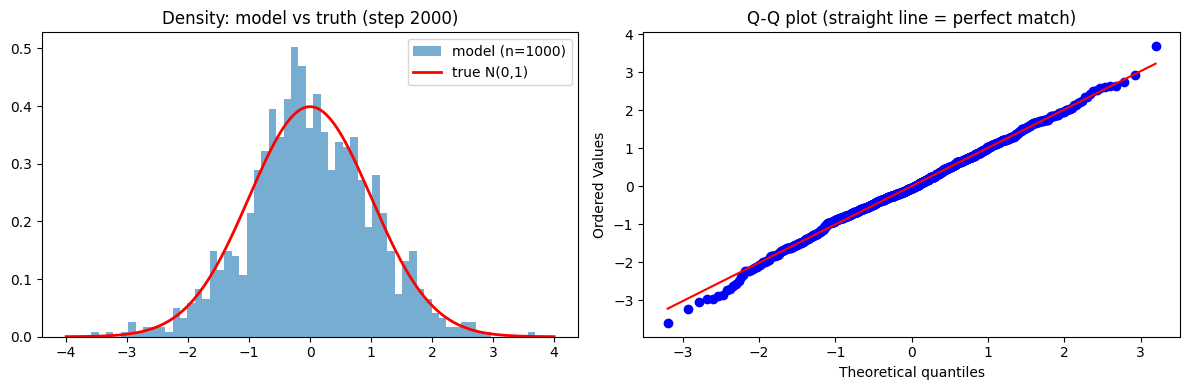

In [97]:
def plot_eval_distribution(eval_history, step=2000):
    if not eval_history:
        raise ValueError('eval_history is empty; run the training cell first.')

    record = min(eval_history, key=lambda r: abs(r['step'] - step))
    by_mean = record['by_mean']
    n = len(by_mean)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), squeeze=False)

    clean_by_mean = {}
    for row, (mu, rec) in enumerate(sorted(by_mean.items())):
        sigma = rec['sigma']
        all_nums = rec['all_nums']
        clean = all_nums[np.abs(all_nums) < 10]
        clean_by_mean[mu] = clean

        xs = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        axes[row, 0].hist(clean, bins=50, density=True, alpha=0.6, label=f"model (n={len(clean)})")
        axes[row, 0].plot(xs, stats.norm.pdf(xs, mu, sigma), 'r-', lw=2, label=f'true N({mu:.1f},{sigma:.1f})')
        axes[row, 0].set_title(f"Density at mu={mu:+.1f}, step {record['step']}")
        axes[row, 0].legend()

        stats.probplot(clean, dist=stats.norm(loc=mu, scale=sigma), plot=axes[row, 1])
        axes[row, 1].set_title(f'Q-Q plot at mu={mu:+.1f}')

    plt.tight_layout()
    plt.show()

    return clean_by_mean, record


clean_by_mean_2k, eval_2k = plot_eval_distribution(eval_history, step=2000)

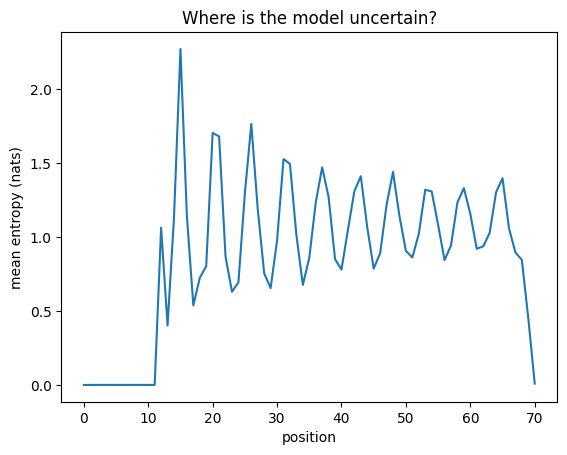

In [98]:
def plot_entropy_by_position(model, eval_examples, n_eval=256):
    eval_toks, eval_mask = collate(eval_examples[:n_eval])
    eval_toks, eval_mask = eval_toks.to(device), eval_mask.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(eval_toks[:, :-1])
        probs = F.softmax(logits, dim=-1)
        ent = -(probs * (probs + 1e-12).log()).sum(-1)  # (B, L-1)
        mask = eval_mask[:, 1:].bool()
        per_pos = (ent * mask).sum(0) / mask.sum(0).clamp(min=1)
    model.train()

    plt.plot(per_pos.cpu().numpy())
    plt.xlabel('position')
    plt.ylabel('mean entropy (nats)')
    plt.title('Uncertainty by position across mean-sweep prompts')
    plt.show()

    return per_pos.cpu().numpy()


per_pos_entropy = plot_entropy_by_position(model, eval_examples)

Try on different mu values:

In [99]:
def make_rung3_dataset(n_examples=5000, n_samples=10, seed=0):
    rng = np.random.default_rng(seed)
    examples = []
    metadata = []  # store the true params for later eval
    for _ in range(n_examples):
        mu = rng.uniform(-3.0, 3.0)
        sigma = 1.0
        samples = rng.normal(mu, sigma, n_samples)
        toks, start = build_sequence('normal', [mu, sigma], samples)
        examples.append((toks, start))
        metadata.append((mu, sigma))
    return examples, metadata

In [102]:
def parse_samples_robust(text, plausible_range=10.0):
    nums, malformed = [], 0
    for s in text.split(','):
        s = s.strip()
        try:
            x = float(s)
            if abs(x) <= plausible_range:
                nums.append(x)
            else:
                malformed += 1
        except ValueError:
            malformed += 1
    return nums, malformed

In [101]:
@torch.no_grad()
def conditional_eval(model, mu_grid=(-2.5, -1.5, -0.5, 0.5, 1.5, 2.5),
                     n_runs=50, n_samples=10):
    results = []
    for mu in mu_grid:
        all_nums = []
        for _ in range(n_runs):
            nums, _ = parse_samples_robust(generate_text(model, 'normal', (mu, 1.0)))
            all_nums.extend(nums)
        all_nums = np.array(all_nums)
        # robust filter relative to expected location
        clean = all_nums[np.abs(all_nums - mu) < 5.0]
        results.append({
            'mu_requested': mu,
            'mu_observed': clean.mean() if len(clean) else np.nan,
            'std_observed': clean.std() if len(clean) else np.nan,
            'n_clean': len(clean),
        })
    for r in results:
        print(f"  μ_req={r['mu_requested']:+.2f}  →  "
              f"μ_obs={r['mu_observed']:+.3f}  "
              f"σ_obs={r['std_observed']:.3f}  "
              f"n={r['n_clean']}")
    return results

In [103]:
# Rung 3: condition on different means, fixed sigma.
# This cell is self-contained except for TinyGPT/build_sequence/collate/VOCAB globals above.

from scipy import stats


def parse_samples_conservative(text, plausible_range=10.0):
    nums, malformed = [], 0
    for s in text.split(','):
        s = s.strip()
        try:
            x = float(s)
            if abs(x) <= plausible_range:
                nums.append(x)
            else:
                malformed += 1
        except ValueError:
            malformed += 1
    return nums, malformed


@torch.no_grad()
def generate_text(model, dist='normal', params=(0.0, 1.0), n_samples=10,
                  max_new_tokens=None, temperature=1.0):
    model.eval()
    device = next(model.parameters()).device
    toks = [BOS, STOI[f'<{dist.upper()}>']]
    for p in params:
        toks.append(P)
        toks.extend(encode_number(fmt(p)))
    toks.append(SEP)

    if max_new_tokens is None:
        max_new_tokens = n_samples * 8 + 8

    for _ in range(max_new_tokens):
        x = torch.tensor(toks, device=device).unsqueeze(0)
        logits = model(x)[0, -1] / temperature
        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1).item()
        toks.append(nxt)
        if nxt == EOS:
            break

    tail_start = toks.index(SEP) + 1
    text = ''.join(ITOS[t] for t in toks[tail_start:] if ITOS[t] not in SPECIALS)
    model.train()
    return text


def generate_numbers(model, mu, sigma=1.0, n_samples=10, temperature=1.0):
    text = generate_text(model, 'normal', (mu, sigma), n_samples=n_samples, temperature=temperature)
    nums, malformed = parse_samples_conservative(text)
    return nums, malformed, text


def make_rung3_dataset(n_examples=5_000, n_samples=10, mu_range=(-3.0, 3.0), sigma=1.0, seed=0):
    rng = np.random.default_rng(seed)
    examples, metadata = [], []
    for _ in range(n_examples):
        mu = float(rng.uniform(*mu_range))
        samples = rng.normal(mu, sigma, n_samples)
        toks, start = build_sequence('normal', [mu, sigma], samples)
        examples.append((toks, start))
        metadata.append({'mu': mu, 'sigma': sigma})
    return examples, metadata


@torch.no_grad()
def conditional_eval(model, mu_grid=(-2.5, -1.5, -0.5, 0.5, 1.5, 2.5),
                     sigma=1.0, n_runs=50, n_samples=10, temperature=1.0):
    results = []
    for mu in mu_grid:
        all_nums, malformed, raw_texts = [], 0, []
        for _ in range(n_runs):
            nums, bad, text = generate_numbers(model, mu, sigma, n_samples, temperature)
            all_nums.extend(nums)
            malformed += bad
            raw_texts.append(text)

        all_nums = np.array(all_nums, dtype=float)
        clean = all_nums[np.abs(all_nums - mu) < 5.0]
        expected = n_runs * n_samples
        ks = stats.kstest(clean, 'norm', args=(mu, sigma)) if len(clean) > 30 else None
        results.append({
            'mu_requested': float(mu),
            'sigma_requested': float(sigma),
            'mu_observed': float(clean.mean()) if len(clean) else np.nan,
            'std_observed': float(clean.std()) if len(clean) else np.nan,
            'parse_rate': float(len(all_nums) / expected),
            'malformed': int(malformed),
            'n_clean': int(len(clean)),
            'ks_stat': float(ks.statistic) if ks else np.nan,
            'ks_pvalue': float(ks.pvalue) if ks else np.nan,
            'samples': all_nums,
            'clean': clean,
            'raw_texts': raw_texts,
        })

    for r in results:
        print(f"  mu_req={r['mu_requested']:+.2f}  ->  "
              f"mu_obs={r['mu_observed']:+.3f}  "
              f"sigma_obs={r['std_observed']:.3f}  "
              f"parse={r['parse_rate']:.1%}  bad={r['malformed']}  "
              f"KS={r['ks_stat']:.3f}  n={r['n_clean']}")
    return results


# Data: random means, same sigma.
device = 'cpu'
rung3_sigma = 1.0
train_examples, train_meta = make_rung3_dataset(n_examples=5_000, sigma=rung3_sigma, seed=0)
eval_examples, eval_meta = make_rung3_dataset(n_examples=500, sigma=rung3_sigma, seed=999)
train_loader = DataLoader(train_examples, batch_size=64, shuffle=True, collate_fn=collate)

# Train.
model = TinyGPT(len(VOCAB), max_len=256, d=128, n_heads=4, n_layers=3).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
train_losses, rung3_eval_history = [], []
step, log_every, eval_every = 0, 100, 500
mu_grid = (-2.5, -1.5, -0.5, 0.5, 1.5, 2.5)

for epoch in range(30):
    for toks, mask in train_loader:
        toks, mask = toks.to(device), mask.to(device)
        logits = model(toks[:, :-1])
        targets = toks[:, 1:]
        shifted_mask = mask[:, 1:].float()

        loss_per_tok = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            reduction='none'
        )
        loss = (loss_per_tok * shifted_mask.reshape(-1)).sum() / shifted_mask.sum()

        opt.zero_grad()
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % log_every == 0:
            print(f"step {step:5d}  loss {loss.item():.4f}  grad_norm {gn:.3f}")
            train_losses.append({'step': step, 'loss': float(loss.item()), 'grad_norm': float(gn)})

        if step % eval_every == 0 and step > 0:
            eval_result = conditional_eval(model, mu_grid=mu_grid, sigma=rung3_sigma)
            rung3_eval_history.append({'step': step, 'results': eval_result})

        step += 1


step     0  loss 3.1058  grad_norm 1.983
step   100  loss 1.2733  grad_norm 0.363
step   200  loss 1.1441  grad_norm 0.522
step   300  loss 1.1134  grad_norm 0.264
step   400  loss 1.1225  grad_norm 0.448
step   500  loss 1.1256  grad_norm 0.233
  mu_req=-2.50  ->  mu_obs=-2.485  sigma_obs=1.125  parse=98.8%  bad=4  KS=0.050  n=493
  mu_req=-1.50  ->  mu_obs=-1.475  sigma_obs=1.063  parse=99.8%  bad=2  KS=0.053  n=499
  mu_req=-0.50  ->  mu_obs=-0.441  sigma_obs=1.039  parse=98.4%  bad=7  KS=0.095  n=492
  mu_req=+0.50  ->  mu_obs=+0.372  sigma_obs=1.092  parse=99.4%  bad=2  KS=0.081  n=497
  mu_req=+1.50  ->  mu_obs=+1.263  sigma_obs=1.051  parse=99.2%  bad=3  KS=0.120  n=495
  mu_req=+2.50  ->  mu_obs=+2.343  sigma_obs=1.114  parse=99.8%  bad=2  KS=0.094  n=498
step   600  loss 1.0875  grad_norm 0.303
step   700  loss 1.1087  grad_norm 0.224
step   800  loss 1.0889  grad_norm 0.157
step   900  loss 1.0978  grad_norm 0.285
step  1000  loss 1.0962  grad_norm 0.121
  mu_req=-2.50  ->  m

In [ ]:
# Plots for conditional_eval / rung3_eval_history.


def plot_conditional_eval(results=None, model=None, mu_grid=(-2.5, -1.5, -0.5, 0.5, 1.5, 2.5),
                          sigma=1.0, n_runs=50, n_samples=10):
    if results is None:
        if 'rung3_eval_history' in globals() and rung3_eval_history:
            results = rung3_eval_history[-1]['results']
        elif model is not None:
            results = conditional_eval(model, mu_grid=mu_grid, sigma=sigma,
                                       n_runs=n_runs, n_samples=n_samples)
        else:
            raise ValueError('Provide results/model or run training until rung3_eval_history is non-empty.')

    mus = np.array([r['mu_requested'] for r in results], dtype=float)
    obs = np.array([r['mu_observed'] for r in results], dtype=float)
    stds = np.array([r['std_observed'] for r in results], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(mus, obs, 'o-', label='model')
    axes[0].plot(mus, mus, 'k--', label='ideal')
    axes[0].set_xlabel('requested mu')
    axes[0].set_ylabel('observed mean')
    axes[0].set_title('Conditional mean tracking')
    axes[0].legend()

    axes[1].plot(mus, stds, 'o-', label='model')
    axes[1].axhline(sigma, color='k', linestyle='--', label='ideal sigma')
    axes[1].set_xlabel('requested mu')
    axes[1].set_ylabel('observed std')
    axes[1].set_title('Conditional variance stability')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(results), 1, figsize=(7, 2.4 * len(results)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, results):
        mu = r['mu_requested']
        clean = r.get('clean')
        if clean is None:
            clean = r.get('samples', np.array([]))
            clean = clean[np.abs(clean - mu) < 5.0]
        xs = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        ax.hist(clean, bins=40, density=True, alpha=0.6, label=f"model (n={len(clean)})")
        ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'r-', lw=2, label='truth')
        ax.set_title(f"mu={mu:+.2f}: generated density vs N(mu, 1)")
        ax.legend()

    plt.tight_layout()
    plt.show()
    return results


conditional_eval_plots = plot_conditional_eval()